In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'


import torch
from hydra.utils import instantiate
from hydra import initialize, compose
import hydra

import wandb

from data.dataManager import DataManager
from model.modelCreator import ModelCreator
from omegaconf import OmegaConf
from scripts.run import setup_model, load_model_instance
from model.rbm.rbm_two_partite import RBM_TwoPartite

from utils.dwave.experiments import run_hamming_cliff_classical_only
from utils.dwave.plots import plot_hamming_magnetization_classical, plot_hamming_correlations_classical, plot_hamming_cliff_comparison
from utils.pca_utils import load_data, run_pca_pipeline, load_data_features
from utils.rbm.rbm_plots import plot_pca_analysis, prepare_dataframe, plot_pca_analysis_with_energy, prepare_dataframe_incident_energy, plot_pca_analysis_with_features, prepare_dataframe_features
from datetime import datetime
import os
from scripts.RBM_2P_MNIST import save_clamped_samples_for_vae



[22:06:16.067] INFO   CaloQuVAE                                         Loading configuration.
[22:06:17.556] INFO   numexpr.utils                                     Note: detected 96 virtual cores but NumExpr set to maximum of 64, check "NUMEXPR_MAX_THREADS" environment variable.
[22:06:17.557] INFO   numexpr.utils                                     Note: NumExpr detected 96 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
[22:06:17.559] INFO   numexpr.utils                                     NumExpr defaulting to 16 threads.


In [2]:
hydra.core.global_hydra.GlobalHydra.instance().clear()
initialize(version_base=None, config_path="config")
cfg=compose(config_name="config.yaml")
wandb.init(tags = [cfg.data.dataset_name], project=cfg.wandb.project, entity=cfg.wandb.entity, config=OmegaConf.to_container(cfg, resolve=True), mode='disabled')


config = OmegaConf.load(cfg.config_path)
config.gpu_list = cfg.gpu_list
config.load_state = cfg.load_state
self = setup_model(config)
self._model_creator.load_state(config.run_path, self.device)

rbm_cfg=compose(config_name="config.yaml")


dummy_data = torch.zeros(1, rbm_cfg.rbm.num_visible_nodes).to(self.device)
# CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-02-08_22-42-25_RBM_TwoPartite/training_checkpoint.h5"
CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-02-04_18-53-39_RBM_TwoPartite/training_checkpoint.h5"
rbm = RBM_TwoPartite(rbm_cfg, data=dummy_data)

print(f"Instantiated RBM with {rbm.num_visible} visible units.")

# --- Step 5: Load the checkpoint ---
# This loads the saved weights, chains, and RNG state *into* the object
try:
    # Load the latest epoch (epoch=None)
    loaded_epoch = rbm.load_checkpoint(CHECKPOINT_FILE, epoch=None) 
    print(f"Successfully loaded checkpoint from epoch {loaded_epoch}.")
except Exception as e:
    print(f"Error loading checkpoint: {e}")

# --- Step 6: Access the data ---
if 'rbm' in locals():
    print("\nAccessing loaded data:")
    
    # Access parameters
    weights = rbm.params["weight_matrix"]
    vbias = rbm.params["vbias"]
    print(f"  Weight matrix shape: {weights.shape}")
    print(f"  Visible bias mean: {vbias.mean().item():.4f}")
    
    # Access persistent chains
    chains = rbm.chains["v"]
    print(f"  Persistent chains shape: {chains.shape}")

[22:06:21.912] INFO   data.dataManager                                  Loading ATLAS dataset: AtlasCustom2
[22:06:27.253] INFO   data.dataManager                                  Using pre-calculated stratified splits: Tr=399991, Val=49994
[22:06:27.256] INFO   data.dataManager                                  Train: 399991 events, 782 batches
[22:06:27.258] INFO   data.dataManager                                  Val: 49994 events, 49 batches
[22:06:27.259] INFO   data.dataManager                                  Test: 50015 events, 49 batches
[22:06:27.260] INFO   model.modelCreator                                ::Creating Model
[22:06:27.262] INFO   model.autoencoder.autoencoderbase                 Using smoothing_dist: gumbel
[22:06:44.840] INFO   model.rbm.zephyr                                  RBM is configured to be fully connected.
[22:06:44.843] INFO   model.rbm.rbm_fulltorch                           RBMTorchFull initialized
[22:06:44.952] INFO   scripts.run               

cuda:4


[22:06:45.379] INFO   engine.engine                                     Using separate beta annealing: beta_latent starts at 1.0, beta_hits starts at 1.0
[22:07:02.929] INFO   model.modelCreator                                Loading state
[22:07:03.032] INFO   model.modelCreator                                Loading weights from file : /fast_scratch_1/caloqvae/lzhu/wandb/run-20260201_060614-qzote2wu/files/ae_separate_best_epoch145.pth
[22:07:03.100] INFO   model.rbm.rbm_two_partite                         Initializing RBM parameters with std: 0.0001
[22:07:03.145] INFO   model.rbm.rbm_two_partite                         Loading parameters from epoch_1999...
[22:07:03.212] INFO   model.rbm.rbm_two_partite                         Loaded persistent chains.
[22:07:03.213] INFO   model.rbm.rbm_two_partite                         Restoring RNG states...


Loading weights for module =  _hit_smoothing_dist_mod
Loading weights for module =  _bce_loss
Loading weights for module =  feature_extractor
Loading weights for module =  cond_normalizer
Loading weights for module =  encoder
Loading weights for module =  prior
Loading weights for module =  decoder
Instantiated RBM with 124 visible units.
Successfully loaded checkpoint from epoch 1999.

Accessing loaded data:
  Weight matrix shape: torch.Size([127, 75])
  Visible bias mean: 0.1775
  Persistent chains shape: torch.Size([5000, 127])


In [3]:
dummy_data = torch.zeros(1, cfg.rbm.latent_nodes_per_p).to(self.device)
CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2025-12-20_05-26-22_RBM_TwoPartite/training_checkpoint.h5"
rbm_binary = RBM_TwoPartite(cfg, data=dummy_data)

try:
    # Load the latest epoch (epoch=None)
    loaded_epoch = rbm_binary.load_checkpoint(CHECKPOINT_FILE, epoch=None) 
    print(f"Successfully loaded checkpoint from epoch {loaded_epoch}.")
except Exception as e:
    print(f"Error loading checkpoint: {e}")

rbm_binary.remove_visible_node_at_index(52)


[22:07:03.314] INFO   model.rbm.rbm_two_partite                         Initializing RBM parameters with std: 0.0001
[22:07:03.317] INFO   model.rbm.rbm_two_partite                         Loading parameters from epoch_1999...
[22:07:03.322] INFO   model.rbm.rbm_two_partite                         Loaded persistent chains.
[22:07:03.322] INFO   model.rbm.rbm_two_partite                         Restoring RNG states...
[22:07:03.325] WARN   model.rbm.rbm_two_partite                         Removing visible node at index 52. Old num_visible: 124
[22:07:03.341] INFO   model.rbm.rbm_two_partite                         Successfully removed node 52. New num_visible: 123


Successfully loaded checkpoint from epoch 1999.


--- Starting Hamming Cliff Experiment (Classical Only): (131072, 131071) ---

Processing Energy: 131072 MeV
  > Sampling Classical RBM (2000 steps)...

Processing Energy: 131071 MeV
  > Sampling Classical RBM (2000 steps)...
--- Starting Hamming Cliff Experiment (Classical Only): (131072, 131071) ---

Processing Energy: 131072 MeV
  > Sampling Classical RBM (2000 steps)...

Processing Energy: 131071 MeV
  > Sampling Classical RBM (2000 steps)...


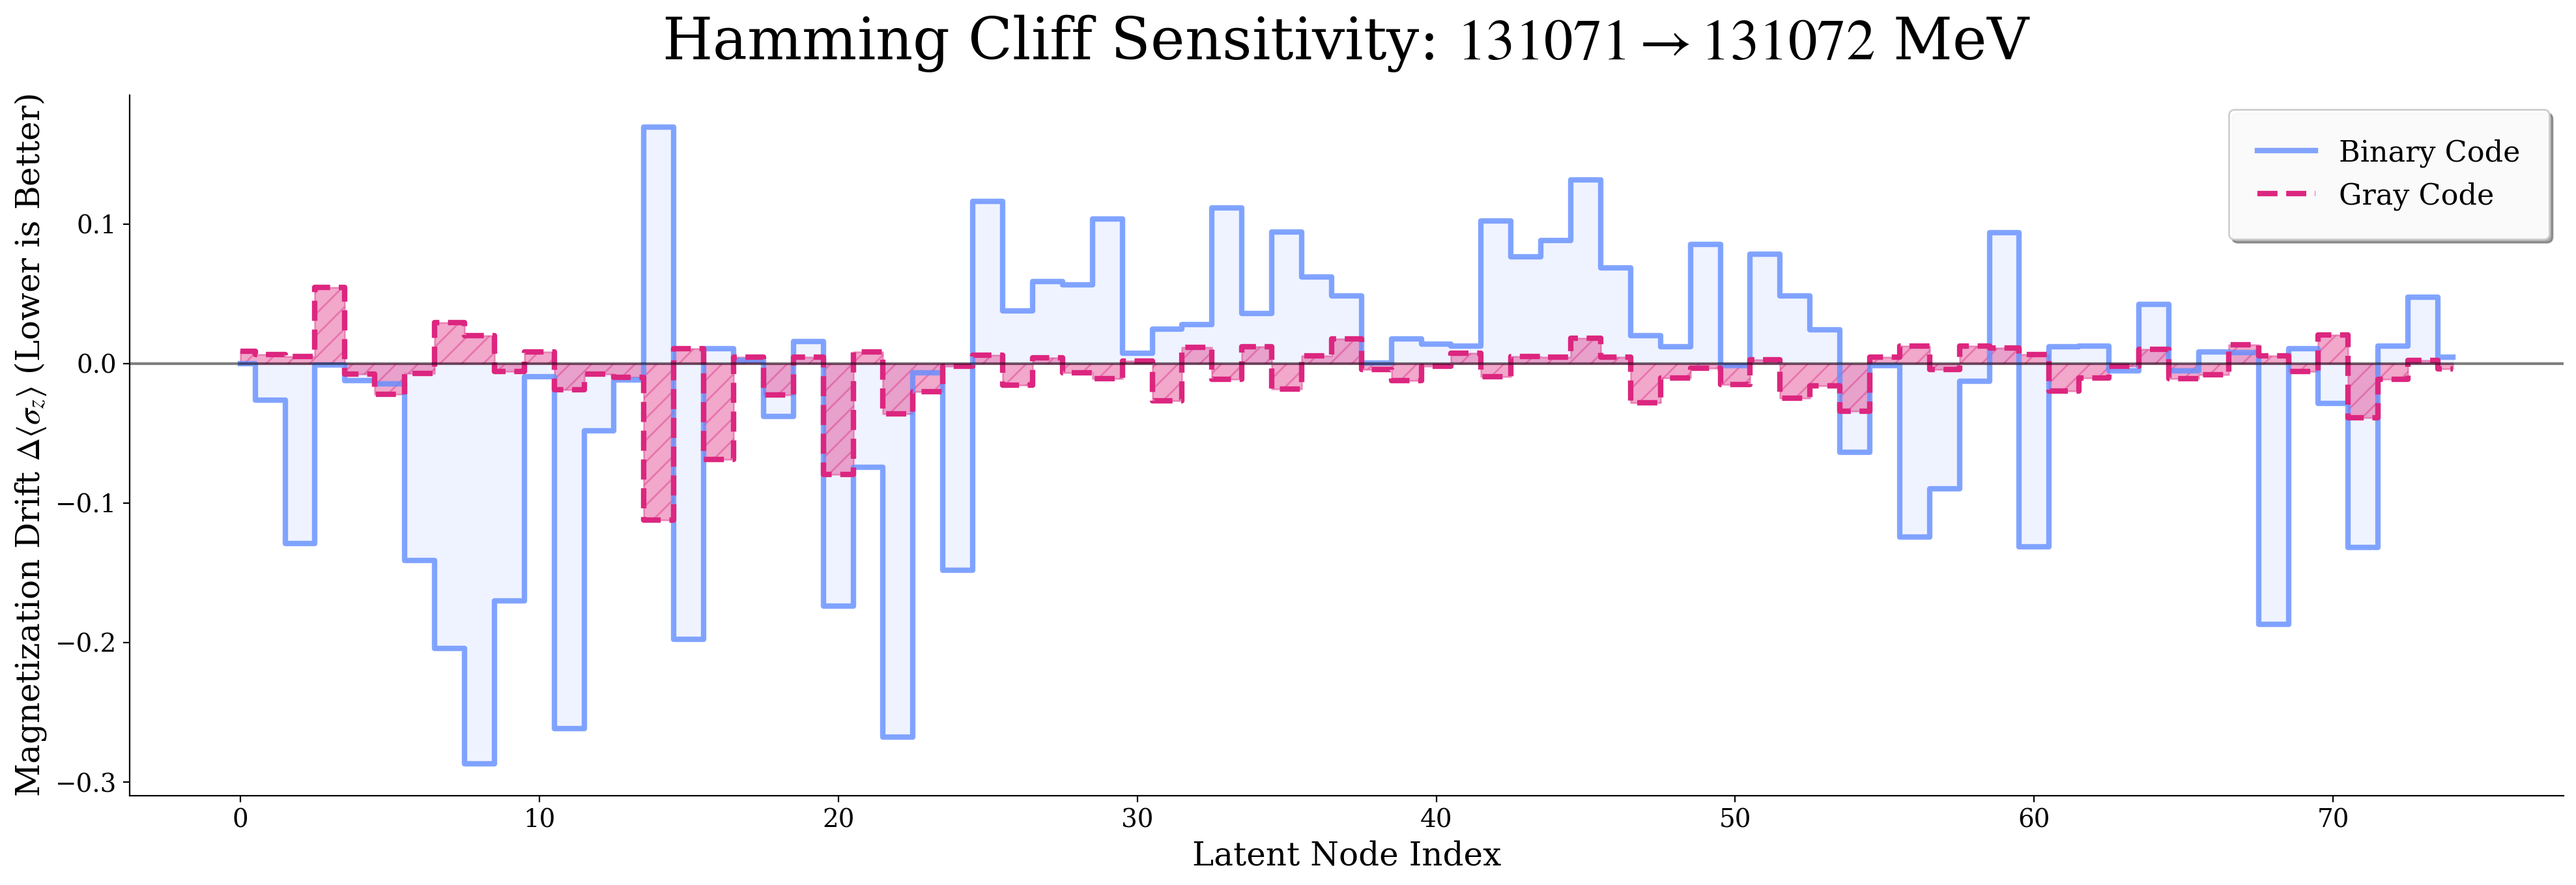

In [ ]:
energy_pair = (2**17, 2**17-1)
hamming_results_gray = run_hamming_cliff_classical_only(energy_pair=energy_pair, engine=self, rbm=rbm, n_cond=52)
# plot_hamming_magnetization_classical(hamming_results_gray, n_cond=52)
# plot_hamming_correlations_classical(hamming_results_gray, n_cond=52)
hamming_results_binary = run_hamming_cliff_classical_only(energy_pair=energy_pair, engine=self, rbm=rbm_binary, n_cond=52, use_gray=False)
# plot_hamming_magnetization_classical(hamming_results_binary, n_cond=52)
# plot_hamming_correlations_classical(hamming_results_binary, n_cond=52)
fig = plot_hamming_cliff_comparison(results_binary=hamming_results_binary, results_gray=hamming_results_gray, n_cond=52)
fig.savefig("hamming_cliff_comparison.png", dpi=300)

In [ ]:
for validation_dataset in cfg.validation_datasets[3:4]:
    val_cfg = compose(config_name="config", overrides=[f"data={validation_dataset}"])    
    val_data_manager = DataManager(val_cfg)
    self.evaluate_ae(val_data_manager.val_loader, 0)
    run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    wandb_output_path = "/home/leozhu/CaloQuVAE/wandb-outputs"
    save_dir = os.path.join(
        wandb_output_path, f"rbm_clamped_samples_{run_timestamp}_{validation_dataset}"
    )
    os.makedirs(save_dir, exist_ok=True)
    torch.save(self.post_samples, os.path.join(save_dir, "post_samples.pt"))
    torch.save(self.incident_energy, os.path.join(save_dir, "incident_energy.pt"))

    prior_samples_path = save_clamped_samples_for_vae(
    rbm,
    input_data=self.post_samples,
    n_clamped=49,
    gibbs_steps=10000,
    save_dir=save_dir,
    gen_batch_size=1024
    )
    rbm_samples = torch.load(prior_samples_path)
    classical_showers, _ = self.generate_showers_from_rbm(rbm_samples, self.incident_energy)
    names = ["recon", "classical"]
    for i, showers in enumerate([self.showers_recon, classical_showers]):
        self.model.feature_extractor.to("cpu")
        self.model.feature_extractor.eval()
        with torch.no_grad():
            features = self.model.feature_extractor(showers)
        layer_1_phi = features["Phi_center"][:, 1]
        torch.save(layer_1_phi, os.path.join(save_dir, f"layer_1_phi_{names[i]}.pt"))


        


In [ ]:
REAL_PATH = "/home/leozhu/CaloQuVAE/wandb-outputs/rbm_clamped_samples_2026-02-11_23-21-53_AtlasCustom50GeV/post_samples.pt"
GEN_PATH = "/home/leozhu/CaloQuVAE/wandb-outputs/rbm_clamped_samples_2026-02-11_23-21-53_AtlasCustom50GeV/rbm_clamped_samples_train_data_final.pt"
RECON_FEATURES_PATH = "/home/leozhu/CaloQuVAE/wandb-outputs/rbm_clamped_samples_2026-02-11_23-21-53_AtlasCustom50GeV/layer_1_phi_recon.pt"
CLASSICAL_FEATURES_PATH = "/home/leozhu/CaloQuVAE/wandb-outputs/rbm_clamped_samples_2026-02-11_23-21-53_AtlasCustom50GeV/layer_1_phi_classical.pt"
device = self.device


# 2. Run Analysis
real_data, gen_data, recon_features, classical_features = load_data_features(REAL_PATH, GEN_PATH, RECON_FEATURES_PATH, CLASSICAL_FEATURES_PATH, device)
print(real_data.shape, gen_data.shape)
n_components = 10
# Note: Set center_projection=False to strictly match your original method
proj_real, proj_gen = run_pca_pipeline(
    real_data, 
    gen_data, 
    n_components=n_components, 
    center_projection=False 
)

# 3. Visualize
df, cols = prepare_dataframe_features(proj_real, proj_gen, recon_features, classical_features, n_components=n_components, feature_name="Phi_center_1")
g = plot_pca_analysis_with_features(df, cols, count_threshold=10, feature_name="Phi_center_1")
plt.show()

In [ ]:
REAL_PATH = "/home/leozhu/CaloQuVAE/wandb-outputs/rbm_clamped_samples_2026-02-11_23-21-53_AtlasCustom50GeV/post_samples.pt"
GEN_PATH = "/home/leozhu/CaloQuVAE/wandb-outputs/rbm_clamped_samples_2026-02-11_23-21-53_AtlasCustom50GeV/rbm_clamped_samples_train_data_final.pt"
RECON_FEATURES_PATH = "/home/leozhu/CaloQuVAE/wandb-outputs/rbm_clamped_samples_2026-02-11_23-21-53_AtlasCustom50GeV/layer_1_phi_recon.pt"
CLASSICAL_FEATURES_PATH = "/home/leozhu/CaloQuVAE/wandb-outputs/rbm_clamped_samples_2026-02-11_23-21-53_AtlasCustom50GeV/layer_1_phi_classical.pt"
device = self.device


# 2. Run Analysis
real_data, gen_data, recon_features, classical_features = load_data_features(REAL_PATH, GEN_PATH, recon_features_path=RECON_FEATURES_PATH, classical_features_path=CLASSICAL_FEATURES_PATH, device=device)
print(real_data.shape, gen_data.shape)
n_components = 10
# Note: Set center_projection=False to strictly match your original method
proj_real, proj_gen = run_pca_pipeline(
    real_data, 
    gen_data, 
    n_components=n_components, 
    center_projection=False 
)

# 3. Visualize
df, cols = prepare_dataframe_incident_energy(proj_real, proj_gen, incidence_energy, n_components=n_components)
g = plot_pca_analysis_with_energy(df, cols, count_threshold=10)
plt.show()

In [ ]:
REAL_PATH = "/home/leozhu/CaloQuVAE/wandb-outputs/rbm_clamped_samples_2026-02-11_20-13-37_AtlasCustom1GeV/post_samples.pt"
GEN_PATH = "/home/leozhu/CaloQuVAE/wandb-outputs/rbm_clamped_samples_2026-02-11_20-13-37_AtlasCustom1GeV/rbm_clamped_samples_train_data_final.pt"
device = self.device


# 2. Run Analysis
real_data, gen_data = load_data(REAL_PATH, GEN_PATH, device, incidence_path=None)
# real_data = real_data[:, 49:]  # Remove the 49 clamped nodes
# gen_data = gen_data[:, 49:]  # Remove the 49 clamped nodes
print(real_data.shape, gen_data.shape)
n_components = 10
# Note: Set center_projection=False to strictly match your original method
proj_real, proj_gen = run_pca_pipeline(
    real_data, 
    gen_data, 
    n_components=n_components, 
    center_projection=False 
)

# 3. Visualize
df, cols = prepare_dataframe(proj_real, proj_gen, n_components=n_components)
g = plot_pca_analysis(df, cols, count_threshold=10)
plt.show()

In [ ]:
self.model.feature_extractor.to("cpu")
self.model.feature_extractor.eval()
with torch.no_grad():
    features = self.model.feature_extractor(self.showers)
layer_1_phi = features["Phi_center"][:, 1]
torch.save(self.incident_energy, os.path.join(save_dir, "incident_energy.pt"))
